In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler,RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
import scipy.cluster.hierarchy as sch
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt, seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

In [ ]:
w_dir="/content/drive/MyDrive/DS Lab"
os.chdir(w_dir)
os.getcwd()

'/content/drive/MyDrive/DS Lab'

Riformatto tabella

In [ ]:
df = pd.read_csv('Global Economy Indicators.csv')
col_list=list(df.columns)[3:] #considero solo le variabili economiche
wide= df.pivot(index=' Year ', columns=' Country ', values=col_list) #multi index indice-paese
wide.index = pd.to_datetime(wide.index, format="%Y", errors="coerce")

wide.columns = pd.MultiIndex.from_tuples(
    [(str(v).strip(), str(c).strip()) for v, c in wide.columns],
    names=wide.columns.names
)
vars_available = wide.columns.get_level_values(0).unique().tolist() # -> 23 variabili
countries_available = wide.columns.get_level_values(1).unique().tolist() # -> 220 paesi
wide.head()

AMA exchange rate                                               \
 Country         Afghanistan Albania   Algeria   Andorra Angola  Anguilla   
 Year                                                                       
1970-01-01          0.044998     5.0   4.93706  0.420708    0.0  2.003376   
1971-01-01          0.044998     5.0  4.912638  0.417515    0.0  1.964366   
1972-01-01          0.044998     5.0  4.480515  0.386279    0.0  1.921872   
1973-01-01          0.044998     5.0  3.962495   0.35015    0.0  1.959219   
1974-01-01          0.044998     5.0   4.18075  0.346703    0.0  2.053232   

                                                        ...  \
 Country   Antigua and Barbuda Argentina Armenia Aruba  ...   
 Year                                                   ...   
1970-01-01                 2.0       0.0     NaN  1.79  ...   
1971-01-01            1.974873       0.0     NaN  1.79  ...   
1972-01-01            1.921278       0.0     NaN  1.79  ...   
1973-01-01            1.959219       0.0     NaN  1.79  ...   
1974-01-01            2.053232       0.0     NaN  1.79  ...   

           Gross Domestic Product (GDP)                                     \
 Country                        Vanuatu Venezuela (Bolivarian Republic of)   
 Year                                                                        
1970-01-01                   38009945.0                      13863636364.0   
1971-01-01                   41066477.0                      15227272727.0   
1972-01-01                   54568338.0                      16744186047.0   
1973-01-01                   66567751.0                      20000000000.0   
1974-01-01                   66380251.0                      30465116279.0   

                                                             \
 Country        Viet Nam Yemen Yemen Arab Republic (Former)   
 Year                                                         
1970-01-01  2775103464.0   NaN                  398314813.0   
1971-01-01  3023991667.0   NaN                  471487495.0   
1972-01-01  3236929352.0   NaN                  686981115.0   
1973-01-01  3350311755.0   NaN                  624152132.0   
1974-01-01  3604730807.0   NaN                  758277851.0   

                                                                        \
 Country   Yemen Democratic (Former) Yugoslavia (Former)        Zambia   
 Year                                                                    
1970-01-01               153591228.0       14553599985.0  1544192383.0   
1971-01-01               141640386.0       15801743321.0  1574164973.0   
1972-01-01               158511867.0       16484705882.0  1851647204.0   
1973-01-01               129761375.0       21471934326.0  2349834205.0   
1974-01-01               137896538.0       29706205815.0  2894548228.0   

                                   
 Country   Zanzibar      Zimbabwe  
 Year                              
1970-01-01      NaN  2336518315.0  
1971-01-01      NaN  2701724625.0  
1972-01-01      NaN  3336471760.0  
1973-01-01      NaN  4103781302.0  
1974-01-01      NaN  4938098908.0  

[5 rows x 5060 columns]

In [ ]:
#wide.to_csv('wide.csv')

Funzione robusta per estrarre una serie country×variable (adatta a wide)

In [ ]:
def get_series_for_country(wide,variable_name, country):
    """Ritorna Series indicizzata per date o None se non disponibile."""
    if variable_name is None:
        return None
    try:
        s = wide.xs(variable_name, level=0, axis=1)[country].copy()
        # convert to numeric, preserve index as datetime
        s = pd.to_numeric(s, errors='coerce')
        s.index = pd.to_datetime(s.index,errors='coerce')  # assicurati index datetime
        s = s.sort_index()
        return s
    except Exception:
        return None

In [ ]:
vars_available

['AMA exchange rate',
 'IMF based exchange rate',
 'Population',
 'Currency',
 'Per capita GNI',
 'Agriculture, hunting, forestry, fishing (ISIC A-B)',
 'Changes in inventories',
 'Construction (ISIC F)',
 'Exports of goods and services',
 'Final consumption expenditure',
 'General government final consumption expenditure',
 'Gross capital formation',
 'Gross fixed capital formation (including Acquisitions less disposals of valuables)',
 'Household consumption expenditure (including Non-profit institutions serving households)',
 'Imports of goods and services',
 'Manufacturing (ISIC D)',
 'Mining, Manufacturing, Utilities (ISIC C-E)',
 'Other Activities (ISIC J-P)',
 'Total Value Added',
 'Transport, storage and communication (ISIC I)',
 'Wholesale, retail trade, restaurants and hotels (ISIC G-H)',
 'Gross National Income(GNI) in USD',
 'Gross Domestic Product (GDP)']

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL

# ---------- helper per controllo osservazioni ----------
def enough_obs(s, abs_min=5):
    if s is None:
        return False
    return s.dropna().shape[0] >= abs_min

# ---------- funzione principale: compute_country_features ----------
def compute_country_features(country, wide, min_obs_absolute=10):
    """
    Restituisce un dizionario di features per 'country' usando le variabili disponibili in 'wide'.
    wide: DataFrame index=time, columns=variables (MultiIndex possibile variable/country).
    min_obs_absolute: numero minimo di osservazioni per calcolare una feature basata su quella serie.
    """
    out = {'country': country}

    # VAR NOME USATI — adattali se i nomi nel tuo wide sono diversi
    V = {
        'exports': 'Exports of goods and services',
        'imports': 'Imports of goods and services',
        'gdp': 'Gross Domestic Product (GDP)',
        'gni_usd': 'Gross National Income(GNI) in USD',
        'total_va':  'Total Value Added',
        'agri': 'Agriculture, hunting, forestry, fishing (ISIC A-B)',
        'manufact': 'Manufacturing (ISIC D)',
        'mining_manuf_utils': 'Mining, Manufacturing, Utilities (ISIC C-E)',
        'services_trade': 'Wholesale, retail trade, restaurants and hotels (ISIC G-H)',
        'transport': 'Transport, storage and communication (ISIC I)',
        'household_consumption': 'Household consumption expenditure (including Non-profit institutions serving households)',
        'gov_consumption': 'General government final consumption expenditure',
        'gross_capital_formation': 'Gross capital formation',
        'population': 'Population',
        'ama': 'AMA exchange rate'
    }

    # estrai serie candidate
    s_exports = get_series_for_country(wide,V['exports'], country)
    s_imports = get_series_for_country(wide,V['imports'], country)
    s_gdp = get_series_for_country(wide,V['gdp'], country)
    s_gni = get_series_for_country(wide,V['gni_usd'], country)
    s_total_va = get_series_for_country(wide,V['total_va'], country)
    s_agri = get_series_for_country(wide,V['agri'], country)
    s_manuf = get_series_for_country(wide,V['manufact'], country)
    s_mineman = get_series_for_country(wide,V['mining_manuf_utils'], country)
    s_services = get_series_for_country(wide,V['services_trade'], country)
    s_transport = get_series_for_country(wide,V['transport'], country)
    s_household = get_series_for_country(wide,V['household_consumption'], country)
    s_govcons = get_series_for_country(wide,V['gov_consumption'], country)
    s_gfcf = get_series_for_country(wide,V['gross_capital_formation'], country)
    s_pop = get_series_for_country(wide,V['population'], country)
    s_exc = get_series_for_country(wide,V['ama'], country)

    # helper per growth e volatility su serie di livello
    def logdiff(s):
        if not isinstance(s, pd.Series):
            return None
        s2 = pd.to_numeric(s, errors='coerce').replace(0, np.nan).dropna()
        s2 = s2.where(s2 > 0)  # solo valori positivi
        if s2.shape[0] < 2:
            return None
        return np.log(s2).diff().dropna()

    # --- features legate a GDP / dimensione / livelli ---
    out['n_obs_exports'] = 0 if s_exports is None else int(s_exports.dropna().shape[0])
    out['n_obs_gdp'] = 0 if s_gdp is None else int(s_gdp.dropna().shape[0])

    # sizes / levels (ultima osservazione disponibile)
    try:
        out['gdp_latest'] = float(s_gdp.dropna().iloc[-1]) if enough_obs(s_gdp, min_obs_absolute) else np.nan
    except:
        out['gdp_latest'] = np.nan
    try:
        out['gni_percap_latest'] = float(s_gni.dropna().iloc[-1]) if enough_obs(s_gni, min_obs_absolute) else np.nan
    except:
        out['gni_percap_latest'] = np.nan

    # --- trade shares e openness ---
    if enough_obs(s_exports, min_obs_absolute) and enough_obs(s_gdp, min_obs_absolute):
        try:
            mean_exports = s_exports.dropna().mean()
            mean_gdp = s_gdp.dropna().mean()
            out['exports_share_gdp'] = float(mean_exports / mean_gdp) if mean_gdp != 0 else np.nan
        except:
            out['exports_share_gdp'] = np.nan
    else:
        out['exports_share_gdp'] = np.nan

    if enough_obs(s_imports, min_obs_absolute) and enough_obs(s_gdp, min_obs_absolute):
        try:
            out['imports_share_gdp'] = float(s_imports.dropna().mean() / s_gdp.dropna().mean())
        except:
            out['imports_share_gdp'] = np.nan
    else:
        out['imports_share_gdp'] = np.nan

    # openness
    if not np.isnan(out.get('exports_share_gdp', np.nan)) and not np.isnan(out.get('imports_share_gdp', np.nan)):
        out['trade_openness'] = out['exports_share_gdp'] + out['imports_share_gdp']
    else:
        out['trade_openness'] = np.nan

    # --- dinamiche: growth & volatility su exports / imports / gdp / total value added ---
    exp_g = logdiff(s_exports)
    imp_g = logdiff(s_imports)
    gdp_g = logdiff(s_gdp)
    va_g = logdiff(s_total_va)

    def stat_on_growth(gseries):
        if gseries is None or len(gseries) < 3:
            return {'mean': np.nan, 'vol': np.nan, 'ac1': np.nan, 'down_share': np.nan}
        return {
            'mean': float(gseries.mean()),
            'vol': float(gseries.std()),
            'ac1': float(gseries.autocorr(lag=1)) if hasattr(gseries, 'autocorr') else np.nan,
            'down_share': float((gseries < 0).mean())
        }

    exp_stats = stat_on_growth(exp_g)
    imp_stats = stat_on_growth(imp_g)
    gdp_stats = stat_on_growth(gdp_g)
    va_stats = stat_on_growth(va_g)

    out['exp_mean_growth'] = exp_stats['mean']
    out['exp_vol_growth'] = exp_stats['vol']
    out['exp_ac1'] = exp_stats['ac1']
    out['exp_down_share'] = exp_stats['down_share']

    out['imp_mean_growth'] = imp_stats['mean']
    out['imp_vol_growth'] = imp_stats['vol']

    out['gdp_mean_growth'] = gdp_stats['mean']
    out['gdp_vol_growth'] = gdp_stats['vol']

    out['va_mean_growth'] = va_stats['mean'] if not np.isnan(va_stats['mean']) else np.nan
    out['va_vol_growth'] = va_stats['vol']

    # correlation export vs gdp growth (se allineati)
    try:
        if exp_g is not None and gdp_g is not None:
            idx = exp_g.index.intersection(gdp_g.index)
            if len(idx) >= max(6, min_obs_absolute):
                out['corr_exp_gdp'] = float(np.corrcoef(exp_g.loc[idx].values, gdp_g.loc[idx].values)[0,1])
            else:
                out['corr_exp_gdp'] = np.nan
        else:
            out['corr_exp_gdp'] = np.nan
    except:
        out['corr_exp_gdp'] = np.nan

    # --- composizione settoriale (shares sulla Total Value Added) e diversificazione ---
    # definisco i settori disponibili e cerco di estrarli
    sectors = {
        'agri': s_agri,
        'manufact': s_manuf,
        'mining_manuf_utils': s_mineman,
        'services_trade': s_services,
        'transport': s_transport
    }
    # calcolo share media di ciascun settore su total value added, ove possibile
    sector_shares = {}
    for k, s in sectors.items():
        if s is not None and s_total_va is not None and enough_obs(s, min_obs_absolute) and enough_obs(s_total_va, min_obs_absolute):
            try:
                sector_shares[k] = float(s.dropna().mean() / s_total_va.dropna().mean())
            except:
                sector_shares[k] = np.nan
        else:
            sector_shares[k] = np.nan
    # inserisco nel dizionario out
    for k, v in sector_shares.items():
        out[f'{k}_share_va'] = v

    # Herfindahl-like index di concentrazione settoriale (somme share^2) se almeno 2 share disponibili
    share_vals = np.array([v for v in sector_shares.values() if not np.isnan(v)])
    if len(share_vals) >= 2:
        out['sector_HHI'] = float(np.sum(share_vals**2))
        out['primary_share'] = float(sector_shares.get('agri', np.nan))
        out['manufacturing_share'] = float(sector_shares.get('manufact', np.nan))
    else:
        out['sector_HHI'] = np.nan
        out['primary_share'] = np.nan
        out['manufacturing_share'] = np.nan

    # --- composizione della domanda: consumption/investment/government shares ---
    try:
        if s_household is not None and enough_obs(s_household, min_obs_absolute) and enough_obs(s_gdp, min_obs_absolute):
            out['household_cons_share_gdp'] = float(s_household.dropna().mean() / s_gdp.dropna().mean())
        else:
            out['household_cons_share_gdp'] = np.nan
    except:
        out['household_cons_share_gdp'] = np.nan

    try:
        if s_govcons is not None and enough_obs(s_govcons, min_obs_absolute) and enough_obs(s_gdp, min_obs_absolute):
            out['gov_cons_share_gdp'] = float(s_govcons.dropna().mean() / s_gdp.dropna().mean())
        else:
            out['gov_cons_share_gdp'] = np.nan
    except:
        out['gov_cons_share_gdp'] = np.nan

    try:
        if s_gfcf is not None and enough_obs(s_gfcf, min_obs_absolute) and enough_obs(s_gdp, min_obs_absolute):
            out['inv_share_gdp'] = float(s_gfcf.dropna().mean() / s_gdp.dropna().mean())
        else:
            out['inv_share_gdp'] = np.nan
    except:
        out['inv_share_gdp'] = np.nan

    # --- semplice indicatori di volatilità aggiuntivi e downside risk su GDP/VA ---
    try:
        out['gdp_max_drawdown'] = np.nan
        if s_gdp is not None and enough_obs(s_gdp, min_obs_absolute):
            s_log = np.log(pd.to_numeric(s_gdp, errors='coerce').replace(0, np.nan)).dropna()
            roll_max = s_log.cummax()
            out['gdp_max_drawdown'] = float((s_log - roll_max).min())
    except:
        out['gdp_max_drawdown'] = np.nan

    # --- indicatori aggiuntivi possibili (elasticities), es. beta exports~gdp (pooled regressions non qui) ---
    # leave as NaN for now; we can compute pooled betas externally.

    # --- Population ---
    if enough_obs(s_pop):
      out['population_latest'] = float(s_pop.dropna().iloc[-1])
    else:
        out['population_latest'] = np.nan

    # --- Exchange rate ---
    if enough_obs(s_exc):
        fx_log = np.log(s_exc.replace(0, np.nan)).dropna()
        out['fx_mean'] = float(fx_log.mean())
        out['fx_vol'] = float(fx_log.diff().std()) if fx_log.shape[0] > 1 else np.nan
        out['fx_trend'] = float(np.polyfit(np.arange(len(fx_log)), fx_log.values, 1)[0]) if fx_log.shape[0] > 5 else np.nan
        out['fx_ac1'] = fx_log.autocorr(lag=1)
    else:
        out['fx_mean'] = np.nan
        out['fx_vol'] = np.nan
        out['fx_trend'] = np.nan
        out['fx_ac1'] = np.nan


    return out

In [ ]:
# ---------- loop su tutti i paesi e costruzione features_df ----------
rows = []
for c in countries_available:
    feat = compute_country_features(c, wide, min_obs_absolute=10)
    rows.append(feat)

features_df = pd.DataFrame(rows).set_index('country')
features_df=features_df.iloc[:,2:]
print("Features shape:", features_df.shape)
display(features_df)

Features shape: (220, 33)


,gdp_latest,gni_percap_latest,exports_share_gdp,imports_share_gdp,trade_openness,exp_mean_growth,exp_vol_growth,exp_ac1,exp_down_share,imp_mean_growth,...,manufacturing_share,household_cons_share_gdp,gov_cons_share_gdp,inv_share_gdp,gdp_max_drawdown,population_latest,fx_mean,fx_vol,fx_trend,fx_ac1
country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,1.493901e+10,1.511467e+10,0.172251,0.364170,0.536422,0.046820,0.194478,-0.081318,0.372549,0.066831,...,0.100796,0.911211,0.160878,0.134290,-0.754337,40099462.0,0.412404,0.504206,0.204945,0.988937
Albania,1.826004e+10,1.795620e+10,0.252986,0.422817,0.675803,0.047007,0.263550,0.050655,0.294118,0.054226,...,0.082557,0.778394,0.109555,0.293757,-0.662446,2854710.0,3.455906,0.218847,0.083534,0.988487
Algeria,1.630000e+11,1.600000e+11,0.309228,0.283642,0.592870,0.071485,0.270167,0.123226,0.392157,0.066956,...,0.061124,0.416595,0.170504,0.387949,-0.427091,44177969.0,3.145252,0.137662,0.085257,0.994971
Andorra,3.324648e+09,3.324648e+09,0.268975,0.276089,0.545064,0.089547,0.116866,0.269880,0.176471,0.086323,...,0.041190,0.590200,0.182778,0.234520,-0.381917,79034.0,-0.367179,0.104006,0.015125,0.947911
Angola,7.053324e+10,7.142209e+10,0.486394,0.356770,0.843164,0.061539,0.344462,-0.337072,0.333333,0.043359,...,0.056033,0.432219,0.182105,0.255302,-1.028963,34503774.0,-6.280127,0.942972,0.637952,0.995917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Yemen Democratic (Former),6.544678e+08,6.448735e+08,0.134162,0.985342,1.119504,0.029459,0.217733,-0.251332,0.350000,0.078814,...,0.101732,0.959098,0.478452,0.413630,-0.200132,2912315.0,-0.485551,0.141149,0.019720,0.734022
Yugoslavia (Former),8.816035e+10,9.584355e+10,0.207365,0.252231,0.459596,0.105155,0.180272,0.025496,0.300000,0.104040,...,0.336353,0.519891,0.156426,0.378584,-0.107515,23972172.0,-4.778827,0.598057,0.328164,0.982821
Zambia,2.131337e+10,2.067962e+10,0.383636,0.397693,0.781330,0.044274,0.242471,0.013973,0.431373,0.040094,...,0.108435,0.560550,0.142441,0.293625,-0.717559,19473125.0,-1.891767,0.280165,0.248122,0.997454


# Missing values management e feature selection

In [ ]:
coverage = features_df.notna().mean().sort_values(ascending=False)
print(coverage)

gdp_latest                     1.000000
gni_percap_latest              1.000000
va_vol_growth                  1.000000
gdp_mean_growth                1.000000
gdp_vol_growth                 1.000000
va_mean_growth                 1.000000
manufacturing_share            1.000000
mining_manuf_utils_share_va    1.000000
fx_trend                       1.000000
population_latest              1.000000
gdp_max_drawdown               1.000000
fx_vol                         1.000000
fx_mean                        1.000000
sector_HHI                     1.000000
manufact_share_va              1.000000
exp_vol_growth                 0.995455
exports_share_gdp              0.995455
exp_mean_growth                0.995455
household_cons_share_gdp       0.995455
services_trade_share_va        0.995455
transport_share_va             0.995455
gov_cons_share_gdp             0.995455
exp_down_share                 0.995455
exp_ac1                        0.995455
corr_exp_gdp                   0.995455


Tutte le features hanno almeno il 92% di valori non nulli. Ottimo

In [ ]:
X_keep = features_df.copy()

**Drop di variabili quasi costanti**  
Non ci sono variabili per cui esistano meno di 30 valori diversi tra i vari paesi, quindi il dataset rimane di nuovo invariato.

In [ ]:
nunique = X_keep.nunique(dropna=True)
drop_const = nunique[nunique <= 30].index.tolist()
if drop_const:
    print("Dropping near-constant features:", drop_const)
    X_keep = X_keep.drop(columns=drop_const)


**WINSORIZE per limitare outlier estremi (1st/99th).**  

 Il Winsorizing ha molto senso nel contesto del clustering, specialmente se si usano algoritmi sensibili alla scala dei dati, come K-Means.
 * **Evitare la Distorsione**: I valori anomali (outliers) possono distorcere la distanza tra i punti dati, tirando il centroide di un cluster in una direzione errata. Ad esempio, se un singolo paese ha un valore di PIL estremamente alto, potrebbe dominare il calcolo della distanza e influenzare in modo sproporzionato la formazione dei cluster. Il Winsorizing mitiga questo problema, rendendo i cluster più robusti.
 * **Migliorare la Robustezza**: Molti algoritmi di clustering, tra cui K-Means, dipendono dal calcolo delle distanze euclidee. Un valore estremo in una singola dimensione (colonna) può gonfiare artificialmente la distanza, portando a raggruppamenti meno significativi. Il Winsorizing riduce l'influenza di questi valori, permettendo all'algoritmo di concentrarsi sui pattern della maggioranza dei dati.

In [ ]:
def winsorize_df(df, low=0.01, high=0.99):
    dfw = df.copy()
    for c in df.columns:
        lo = df[c].quantile(low)
        hi = df[c].quantile(high)
        dfw[c] = df[c].clip(lower=lo, upper=hi)
    return dfw

X_w = winsorize_df(X_keep, 0.01, 0.99)

**Imputazione: KNN**

In [ ]:
imp = KNNImputer(n_neighbors=5)
X_imp_np = imp.fit_transform(X_w)
X_imp = pd.DataFrame(X_imp_np, index=X_w.index, columns=X_w.columns)

**RobustScaler**  

A differenza dello StandardScaler (che usa media e deviazione standard), il RobustScaler utilizza la mediana e il range interquartile (IQR) per scalare i dati ed è meno sensibile agli outliers.  
* **Robustezza agli Outlier**: Anche se abbiamo già usato il Winsorizing, il RobustScaler offre un'ulteriore protezione dagli outlier residui o da quelli che non sono stati completamente gestiti. Ciò assicura che il processo di scalatura non venga distorto da valori estremi.
* **Preparazione per il Clustering**: Algoritmi di clustering basati sulla distanza, come K-Means o DBSCAN, sono estremamente sensibili alla scala delle variabili. Se una variabile ha valori molto più grandi di un'altra, dominerà il calcolo della distanza. La scalatura è un passo cruciale per garantire che tutte le variabili abbiano un peso equo nella formazione dei cluster.

In [ ]:
scaler = RobustScaler()
Xs_np = scaler.fit_transform(X_imp)
Xs = pd.DataFrame(Xs_np, index=X_imp.index, columns=X_imp.columns)

**Rimuovo alta correlazione (corr > 0.85)**

In [ ]:
corr = Xs.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]
print("Dropping highly correlated features (>0.85):", to_drop)
Xs2 = Xs.drop(columns=to_drop)

Dropping highly correlated features (>0.85): ['gni_percap_latest', 'trade_openness', 'va_mean_growth', 'va_vol_growth', 'primary_share', 'manufacturing_share']


**Scelta di K (n° cluster ottimale) con inertia + silhouette**

Inertia: {2: 6647.999129897277, 3: 5762.162473708552, 4: 4932.178128744405, 5: 4507.876468975316, 6: 4210.369215387607, 7: 3929.4323320193585, 8: 3674.1029534534414}
Silhouette: {2: np.float64(0.5929056465040363), 3: np.float64(0.21426740818322373), 4: np.float64(0.21073801429793293), 5: np.float64(0.15179717922122032), 6: np.float64(0.14262982180234332), 7: np.float64(0.14993898781870565), 8: np.float64(0.14753048860754805)}


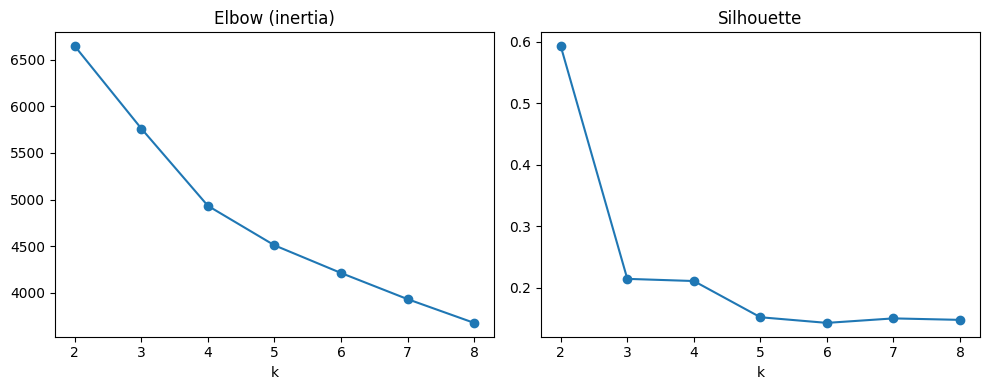

In [ ]:
inertias = {}
silhs = {}
k_range = range(2,9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=20).fit(Xs2)
    inertias[k] = km.inertia_
    silhs[k] = silhouette_score(Xs2, km.labels_)

print("Inertia:", inertias)
print("Silhouette:", silhs)

# plot elbow + silhouette
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(list(inertias.keys()), list(inertias.values()), '-o'); plt.title('Elbow (inertia)'); plt.xlabel('k')
plt.subplot(1,2,2)
plt.plot(list(silhs.keys()), list(silhs.values()), '-o'); plt.title('Silhouette'); plt.xlabel('k')
plt.tight_layout()
plt.show()


L'unico valore di silhouette buono (>0.5) è quello ottimale, che è di gran lunga superiore agli altri. Opereremo dunque un clustering con K=2.

In [ ]:
# final clustering con best k by silhouette
best_k = max(silhs, key=silhs.get)
print("Best k by silhouette:", best_k)
km_final = KMeans(n_clusters=best_k, random_state=0, n_init=50).fit(Xs2)
labels = pd.Series(km_final.labels_, index=Xs2.index, name='cluster')

Best k by silhouette: 2


In [ ]:
# 9) diagnostica cluster
print("Cluster sizes:\n", labels.value_counts().sort_index())
print("Silhouette (final):", silhouette_score(Xs2, labels))

Cluster sizes:
 cluster
0    206
1     14
Name: count, dtype: int64
Silhouette (final): 0.5929056465040363


In [ ]:
labels[labels==1]

,cluster
country,
Australia,1
Brazil,1
Canada,1
China,1
France,1
Germany,1
India,1
Indonesia,1
Italy,1


**KMedoids e confronto ARI**

In [ ]:
 #!pip uninstall numpy -y
 #!pip install numpy==1.26.4
!pip install scikit-learn-extra
from sklearn_extra.cluster import KMedoids

kmed = KMedoids(n_clusters=best_k, random_state=0).fit(Xs2)
labels_kmed = pd.Series(kmed.labels_, index=Xs2.index, name='cluster_kmed')
ari_km_kmed = adjusted_rand_score(labels, labels_kmed)
print("ARI KMeans vs KMedoids:", round(ari_km_kmed,3))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 819.0/819.0 kB 17.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-learn-extra: filename=scikit_learn_extra-0.3.0-cp312-cp312-linux_x86_64.whl size=2176931 sha256=d1f987a344b9748a8f3681721d6d8aec1f1bdd649b4cea6dc2d5c8febdaca0a6
  Stored in directory: /root/.cache/pip/wheels/17/4d/c3/c6d5d563c1bf8146d059d63be3678abc2f2801fba0aaf5f0b8
Successfully built scikit-learn-extra
ARI KMeans vs KMedoids: 0.022


In [ ]:
print("Cluster sizes:\n", labels_kmed.value_counts().sort_index())

NameError: name 'labels_kmed' is not defined

In [ ]:

l0=list()
l1=list()
diz={
    'clust_0':l0,
    'clust_1':l1
}
for c in countries_available:
    if labels_kmed[c] == 0:
        l0.append(c)
    else:
        l1.append(c)

print('Paesi nel cluster 0: ',diz['clust_0'])
print('\nPaesi nel cluster 1',diz['clust_1'])

Paesi nel cluster 0:  ['Algeria', 'Australia', 'Austria', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belgium', 'Bermuda', 'Bhutan', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Burkina Faso', 'Cameroon', 'Canada', 'Cayman Islands', 'Chad', 'Chile', 'China', 'Colombia', 'Congo', 'Cuba', 'Curaçao', 'Czechia', 'Czechoslovakia (Former)', "Côte d'Ivoire", 'D.P.R. of Korea', 'Denmark', 'Ecuador', 'Egypt', 'Equatorial Guinea', 'Ethiopia', 'Ethiopia (Former)', 'Finland', 'Former Netherlands Antilles', 'France', 'French Polynesia', 'Gabon', 'Germany', 'Greenland', 'Hungary', 'India', 'Indonesia', 'Iran (Islamic Republic of)', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Japan', 'Kazakhstan', 'Kenya', 'Kiribati', 'Kosovo', 'Kuwait', 'Libya', 'Liechtenstein', 'Malaysia', 'Mali', 'Marshall Islands', 'Mauritania', 'Mexico', 'Micronesia (FS of)', 'Morocco', 'Myanmar', 'Nauru', 'Nepal', 'Netherlands', 'New Caledonia', 'New Zealand', 'Niger', 'Nigeria', 'Norway', 'Oman', 'Pakistan', 'Panama', 'Philippi

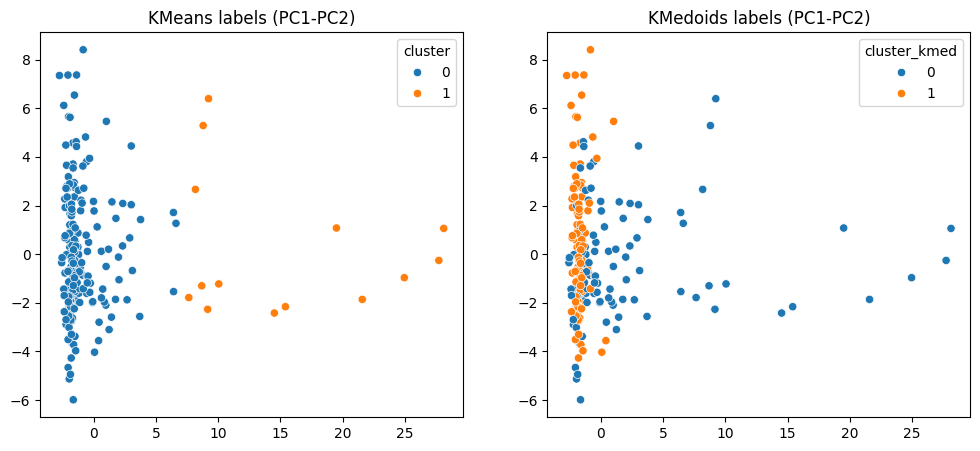

In [ ]:
pca = PCA(n_components=2).fit_transform(Xs2)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1); sns.scatterplot(x=pca[:,0], y=pca[:,1], hue=labels, palette='tab10'); plt.title('KMeans labels (PC1-PC2)')
plt.subplot(1,2,2); sns.scatterplot(x=pca[:,0], y=pca[:,1], hue=labels_kmed, palette='tab10'); plt.title('KMedoids labels (PC1-PC2)')
plt.show()

Discutere Kmeans vs Kmedoids, motivare la scelta di kmeans, citando però anche l'approccio Kmedoids. Evidenziare ARI.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_km = RandomForestClassifier(n_estimators=200, random_state=0).fit(Xs2, labels)
rf_kmed = RandomForestClassifier(n_estimators=200, random_state=0).fit(Xs2, labels_kmed)
imp_km = pd.Series(rf_km.feature_importances_, index=Xs2.columns).sort_values(ascending=False)
imp_kmed = pd.Series(rf_kmed.feature_importances_, index=Xs2.columns).sort_values(ascending=False)
print("Top features KMeans:\n", imp_km.head(10))
print("Top features KMedoids:\n", imp_kmed.head(10))

NameError: name 'labels_kmed' is not defined

In [ ]:
# 1) ARI (già 0.022)
print("ARI kmeans vs kmedoids", adjusted_rand_score(labels, labels_kmed))

# 2) silhouette summary
print("Silhouette KMeans:", silhouette_score(Xs2, labels))
print("Silhouette KMedoids:", silhouette_score(Xs2, labels_kmed))

# 3) Top features difference
print("Top KMeans features:\n", imp_km.head(6))
print("Top KMedoids features:\n", imp_kmed.head(6))

# 4) Medoids list (paesi rappresentativi)
print("Medoids KMedoids:", [Xs2.index[i] for i in kmed.medoid_indices_])

# 5) Forza k=3 per entrambi e confronta assignment
km3 = KMeans(n_clusters=3, random_state=0).fit(Xs2); lab_km3 = pd.Series(km3.labels_, index=Xs2.index)
kmed3 = KMedoids(n_clusters=3, random_state=0).fit(Xs2); lab_kmed3 = pd.Series(kmed3.labels_, index=Xs2.index)
print("ARI k3:", adjusted_rand_score(lab_km3, lab_kmed3))
print("Sil kmeans3", silhouette_score(Xs2, lab_km3), "Sil kmedoids3", silhouette_score(Xs2, lab_kmed3))


ARI kmeans vs kmedoids 0.022267076300077075
Silhouette KMeans: 0.5929053183020386
Silhouette KMedoids: 0.07569168791082721
Top KMeans features:
 gdp_latest           0.342395
population_latest    0.136462
imports_share_gdp    0.084225
exp_vol_growth       0.053535
exports_share_gdp    0.036815
exp_ac1              0.030035
dtype: float64
Top KMedoids features:
 gdp_latest                  0.120668
population_latest           0.085869
household_cons_share_gdp    0.068967
services_trade_share_va     0.068378
fx_ac1                      0.060482
imports_share_gdp           0.054164
dtype: float64
Medoids KMedoids: ['Morocco', 'Honduras']
ARI k3: 0.125363544311194
Sil kmeans3 0.33581423661620585 Sil kmedoids3 0.02859568281084534


**KMedoids e k=3 hanno fornito partizioni alternative interessanti (medoids utili per casi studio) ma le etichette risultavano significativamente diverse da KMeans (ARI molto basso), senza migliorare la chiarezza narrativa per la domanda di ricerca.Inoltre silhouette molto bassa**

**hierarchical dendrogram (quick)**  
A dendogram is a tree-like diagram used to visualize the results of hierarchical clustering. It allowss to visually inspect how the countries are related. We can see a main split between developed and developing nations, with further subdivisions within those groups.

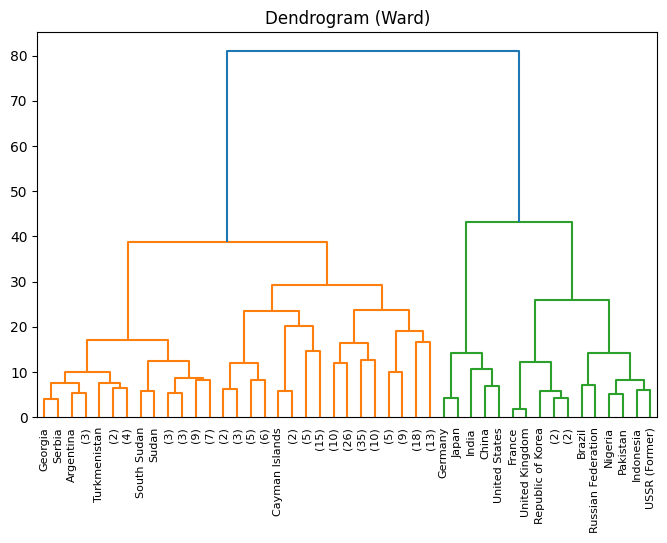

In [ ]:
plt.figure(figsize=(8,5))
Z = sch.linkage(Xs2.values, method='ward')
sch.dendrogram(Z, labels=Xs2.index, leaf_rotation=90, leaf_font_size=8, truncate_mode='level', p=5)
plt.title('Dendrogram (Ward)')
plt.show()

 **Profili cluster (medie sulle features originali non scalate)**  

 Raggruppo il DataFrame X_imp (che contiene i dati originali imputati, ma non ancora scalati) in base alle etichette dei cluster (labels) ottenut in precedenza con K-Means,calcolando la media di ogni feature per ogni gruppo (cluster).  
é uno strumento di interpretazione post-clustering che aiuta a trasformare etichette numeriche (cluster 0, 1) in profili descrittivi e significativi.  
Ho aggiunto una colonna con la differenza percentuale e ordinato le feature per quel valore per identificare rapidamente le variabili chiave che definiscono la separazione tra i cluster.



In [ ]:
profiles = X_imp.groupby(labels).mean().T
profiles['diff_percent'] = abs(profiles[1] - profiles[0]) / (profiles[0]) * 100
profiles_sorted = profiles.sort_values(by='diff_percent', ascending=False)
display(profiles_sorted.round(3))

cluster,0,1,diff_percent
gni_percap_latest,1.200739e+11,2.913543e+12,2326.458
gdp_latest,1.222673e+11,2.871600e+12,2248.625
population_latest,1.942186e+07,1.523240e+08,684.292
exp_ac1,7.700000e-02,1.790000e-01,133.479
agri_share_va,1.340000e-01,5.300000e-02,60.396
primary_share,1.340000e-01,5.300000e-02,60.396
imports_share_gdp,4.920000e-01,2.310000e-01,53.063
manufact_share_va,1.280000e-01,1.910000e-01,49.301
manufacturing_share,1.280000e-01,1.910000e-01,49.301
trade_openness,9.090000e-01,4.710000e-01,48.160


**decision tree surrogate per interpretabilità semplice**
Addestro un Decision Tree per aiutarmi a comprendere la logica dietro la formazione dei cluster, identificando le feature e le regole più importanti che definiscono i gruppi.  
Leggendo le regole che l'albero ha imparato in output, posso vedere quali feature e quali valori di soglia vengono usati dall'albero per dividere i dati e assegnarli a un cluster specifico.  
Le regole dell'albero sono utili per creare una descrizione concisa e intuitiva per ogni cluster. Per esempio, "Il cluster 1 è composto principalmente da paesi con un PIL elevato-->elevata stabilità economica".

In [ ]:
clf = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=0)
clf.fit(Xs2, labels)
print("Decision tree rules:\n")
print(export_text(clf, feature_names=Xs2.columns.tolist()))

Decision tree rules:

|--- gdp_latest <= 8.35
|   |--- gdp_latest <= 4.47
|   |   |--- class: 0
|   |--- gdp_latest >  4.47
|   |   |--- class: 0
|--- gdp_latest >  8.35
|   |--- class: 1



**feature importance (RandomForest su Xs2 -> cluster)**  
 Questo aiuta a identificare le variabili che, complessivamente, sono le più influenti per dividere i paesi in cluster.

In [ ]:
rf = RandomForestClassifier(n_estimators=200, random_state=0)
rf.fit(Xs2, labels)
imp = pd.Series(rf.feature_importances_, index=Xs2.columns).sort_values(ascending=False)
print("Top features (RF importance):")
print(imp.head(20))

Top features (RF importance):
gdp_latest                  0.342395
population_latest           0.136462
imports_share_gdp           0.084225
exp_vol_growth              0.053535
exports_share_gdp           0.036815
exp_ac1                     0.030035
agri_share_va               0.027899
imp_vol_growth              0.024391
imp_mean_growth             0.022717
exp_down_share              0.020960
manufact_share_va           0.018183
fx_vol                      0.017879
fx_mean                     0.017263
gdp_mean_growth             0.016580
sector_HHI                  0.016252
household_cons_share_gdp    0.016051
fx_trend                    0.015873
gov_cons_share_gdp          0.015216
gdp_vol_growth              0.014341
exp_mean_growth             0.013134
dtype: float64



L'analisi ha rivelato che la struttura di base dei cluster è definita principalmente dalla dimensione dell'economia e della popolazione.

Sebbene le economie mondiali siano complesse, la loro struttura di base per il periodo 1970-2021 è definita da una semplice dicotomia tra economie grandi/popolose e piccole. Al limite, solo dopo aver stabilito questa verità fondamentale si può passare ad analizzare le dinamiche più complesse che avvengono all'interno di questi macro-gruppi.


# grafici

**PC scatter (2D)**

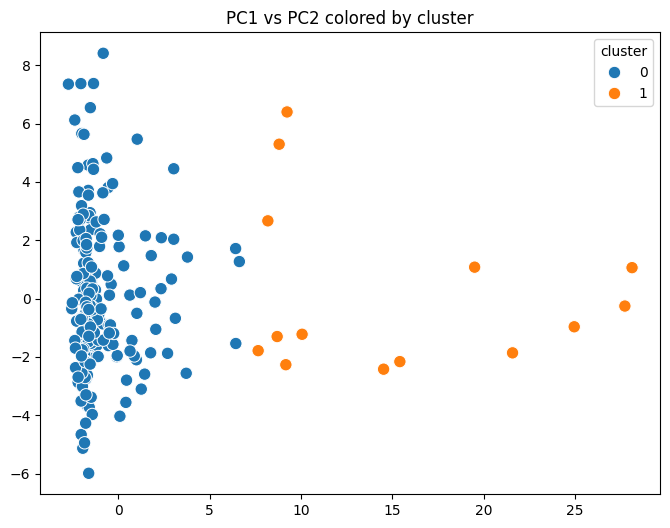

In [ ]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(Xs2)
plt.figure(figsize=(8,6))
sns.scatterplot(x=pcs[:,0], y=pcs[:,1], hue=labels, palette='tab10', s=80)
plt.title('PC1 vs PC2 colored by cluster')
plt.savefig('grafico_pca.pdf', bbox_inches='tight')
plt.show()

**mappa geografica dei paesi divisi per cluster**

In [ ]:
paesi=[c for c in countries_available if labels[c]==1]
paesi

['Australia',
 'Brazil',
 'Canada',
 'China',
 'France',
 'Germany',
 'India',
 'Indonesia',
 'Italy',
 'Japan',
 'Republic of Korea',
 'Russian Federation',
 'United Kingdom',
 'United States']

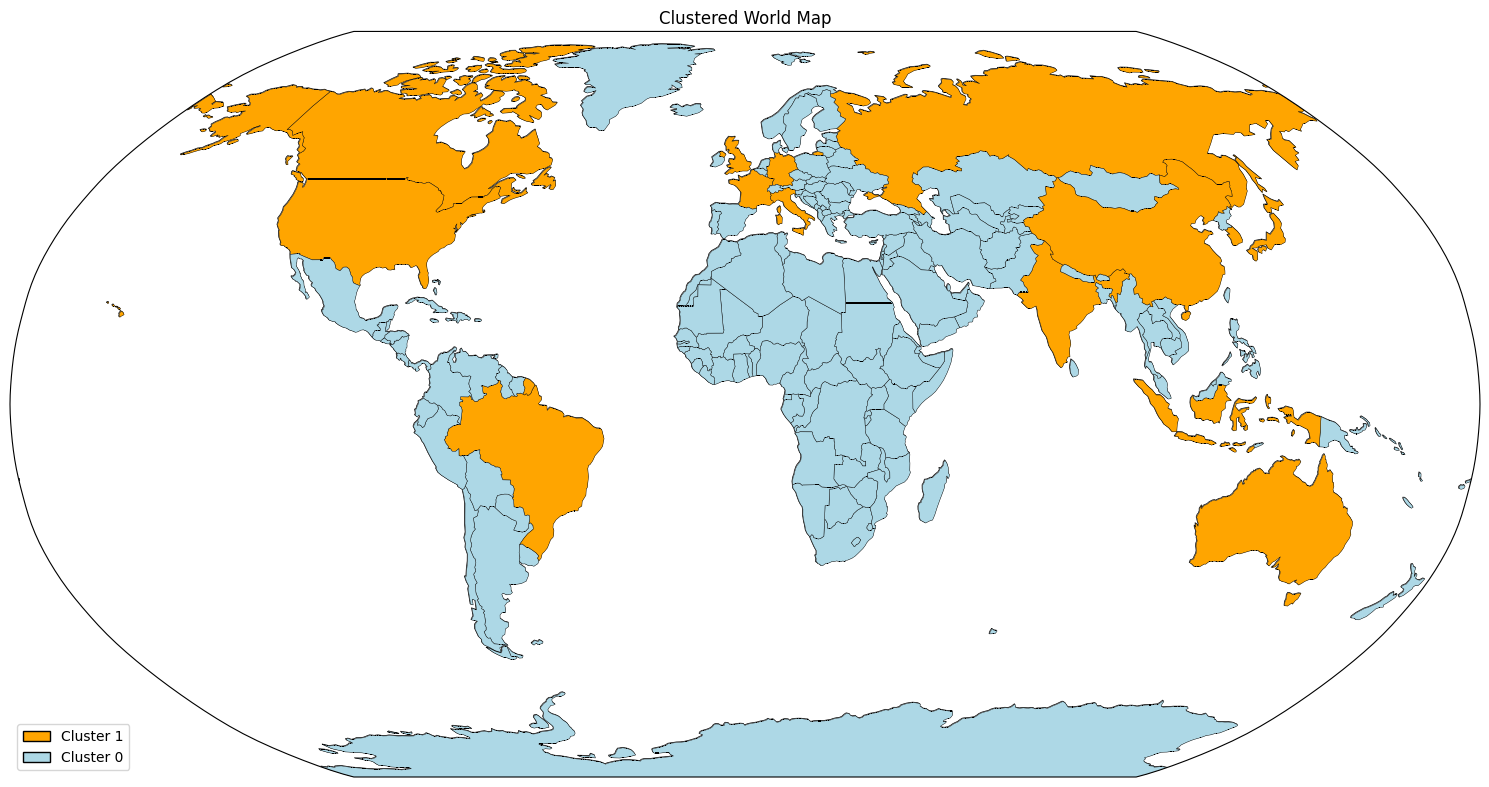

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader
from matplotlib.patches import Patch
import matplotlib.patches as mpatches

cluster1_countries = [
    'Australia', 'Brazil', 'Canada', 'China', 'France', 'Germany',
    'India', 'Indonesia', 'Italy', 'Japan', 'Republic of Korea',
    'Russian Federation', 'United Kingdom', 'United States'
]

# Creazione della figura e della mappa
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()

# Aggiunta delle caratteristiche della mappa
ax.add_feature(cfeature.OCEAN, color='white')
#ax.add_feature(cfeature.LAND, color='lightblue')  # Colore di default per tutti i paesi
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

shapefile = shapereader.natural_earth(resolution='110m', category='cultural', name='admin_0_countries')
reader = shapereader.Reader(shapefile)
countries = reader.records()

for country in countries:
    country_name = country.attributes['NAME_LONG']
    geometry = country.geometry

    if country_name in cluster1_countries:
        color = 'orange'  # Cluster 1
    else:
        color = 'lightblue'  # Cluster 0

    # Aggiungi il paese alla mappa con il colore appropriato
    ax.add_geometries([geometry], ccrs.PlateCarree(),
                      facecolor=color, edgecolor='black', linewidth=0.3)

# Aggiunta della legenda
legend_elements = [
    Patch(facecolor='orange', edgecolor='black', label='Cluster 1'),
    Patch(facecolor='lightblue', edgecolor='black', label='Cluster 0')
]
ax.legend(handles=legend_elements, loc='lower left')

plt.title('Clustered World Map')
plt.tight_layout()
plt.show()

plt.savefig('mappamondo_cluster.png', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.close()

In [ ]:


# # 16) salva risultati
# labels.to_csv('/content/cluster_labels_kmeans.csv')
# profiles.to_csv('/content/cluster_profiles.csv')